# Counterfactual Explanation in Allegro Pay

**Warsaw University of Technology — Final Project**

---

This notebook provides boilerplate code to help you get started. It covers:

1. Environment verification & imports
2. Data loading & initial EDA
3. Feature engineering (skeleton)
4. Feature selection (Boruta)
5. Model training (LightGBM)
6. Model serialization
7. Counterfactual generation (DiCE & Alibi)
8. Evaluation & Benchmarking (DALEX)

> **Instructions:** Fork this repo, fill in the `TODO` sections, and extend the analysis.
> Delete or modify this boilerplate as your project evolves.

## 1. Imports & Configuration

In [ ]:
import numpy as np
print(np.__version__)

1.26.4


In [ ]:
#to dump
pip freeze > reqirements.txt

#to install dependencies 
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [1]:
# Standard library
import pickle
import warnings
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
#import lightgbm as lgb
import xgboost as xgb    # Uncomment if using XGBoost
# import catboost as cb     # Uncomment if using CatBoost

# Counterfactual Explanation packages
import dice_ml
# import alibi               # Uncomment when implementing Alibi

# Project config
import sys
sys.path.insert(0, str(Path.cwd().parent))  # Allow imports from src/
from src.config import (
    RANDOM_SEED,
    DATA_DIR,
    MODELS_DIR,
    TARGET_COLUMN,
    TEST_SIZE,
    N_FEATURES_TO_SELECT,
    N_COUNTERFACTUAL_EXAMPLES,
)

import subprocess
import zipfile

# Reproducibility
np.random.seed(RANDOM_SEED)
warnings.filterwarnings("ignore")

# Plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print(f"Random seed: {RANDOM_SEED}")
print(f"Data directory: {DATA_DIR}")
print(f"Models directory: {MODELS_DIR}")

Random seed: 42
Data directory: C:\Users\stani\wut-counterfactual-explanations\data
Models directory: C:\Users\stani\wut-counterfactual-explanations\models


## 2. Data Loading & Initial EDA

Make sure you have downloaded the data from Kaggle into the `data/` directory.
See the README for download instructions.

In [2]:
# Load the main application training data
app_train = pd.read_csv(DATA_DIR / "application_train.csv")
pd.set_option('display.max_columns', 500)
print(f"Shape: {app_train.shape}")
print(f"\nTarget distribution:\n{app_train[TARGET_COLUMN].value_counts(normalize=True)}")
# Można też 'TARGET'
app_train.head()

Shape: (307511, 122)

Target distribution:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [3]:
bureau = pd.read_csv(DATA_DIR / "bureau.csv")
bureau = bureau[bureau['CREDIT_CURRENCY'] == 'currency 1']
bureau = bureau.drop(columns=['CREDIT_CURRENCY', 'SK_ID_BUREAU'])

num_cols_in_join = bureau.select_dtypes(include='number').columns.drop('SK_ID_CURR', errors='ignore').tolist()  # your numeric columns
cat_cols_in_join = bureau.select_dtypes(include='object').columns.tolist()        # your categorical columns

# numeric: pick what makes sense per column
num_agg = bureau.groupby('SK_ID_CURR')[num_cols_in_join].agg(['max', 'sum', 'median', 'std', 'count'])
num_agg.columns = ['_'.join(col) for col in num_agg.columns]  # flatten column names

# categorical: one-hot counts
#cat_dummies = pd.get_dummies(bureau[['SK_ID_CURR'] + cat_cols_in_join], columns=cat_cols_in_bureau, dummy_na=True)
#cat_agg = cat_dummies.groupby('SK_ID_CURR').sum()
# NIE UMIEM DODAĆ TYCH KATEGORYCZNYCH 

# merge everything
app_train = app_train.merge(num_agg, on='SK_ID_CURR', how='left', suffixes=('', '_bureau'))
    #.merge(cat_agg, on='SK_ID_CURR', how='left')

In [7]:
bureau["CREDIT_ACTIVE"].value_counts()

CREDIT_ACTIVE
Closed      1078062
Active       630426
Sold           6511
Bad debt         21
Name: count, dtype: int64

In [4]:
app_train

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,DAYS_CREDIT_max,DAYS_CREDIT_sum,DAYS_CREDIT_median,DAYS_CREDIT_std,DAYS_CREDIT_count,CREDIT_DAY_OVERDUE_max,CREDIT_DAY_OVERDUE_sum,CREDIT_DAY_OVERDUE_median,CREDIT_DAY_OVERDUE_std,CREDIT_DAY_OVERDUE_count,DAYS_CREDIT_ENDDATE_max,DAYS_CREDIT_ENDDATE_sum,DAYS_CREDIT_ENDDATE_median,DAYS_CREDIT_ENDDATE_std,DAYS_CREDIT_ENDDATE_count,DAYS_ENDDATE_FACT_max,DAYS_ENDDATE_FACT_sum,DAYS_ENDDATE_FACT_median,DAYS_ENDDATE_FACT_std,DAYS_ENDDATE_FACT_count,AMT_CREDIT_MAX_OVERDUE_max,AMT_CREDIT_MAX_OVERDUE_sum,AMT_CREDIT_MAX_OVERDUE_median,AMT_CREDIT_MAX_OVERDUE_std,AMT_CREDIT_MAX_OVERDUE_count,CNT_CREDIT_PROLONG_max,CNT_CREDIT_PROLONG_sum,CNT_CREDIT_PROLONG_median,CNT_CREDIT_PROLONG_std,CNT_CREDIT_PROLONG_count,AMT_CREDIT_SUM_max,AMT_CREDIT_SUM_sum,AMT_CREDIT_SUM_median,AMT_CREDIT_SUM_std,AMT_CREDIT_SUM_count,AMT_CREDIT_SUM_DEBT_max,AMT_CREDIT_SUM_DEBT_sum,AMT_CREDIT_SUM_DEBT_median,AMT_CREDIT_SUM_DEBT_std,AMT_CREDIT_SUM_DEBT_count,AMT_CREDIT_SUM_LIMIT_max,AMT_CREDIT_SUM_LIMIT_sum,AMT_CREDIT_SUM_LIMIT_median,AMT_CREDIT_SUM_LIMIT_std,AMT_CREDIT_SUM_LIMIT_count,AMT_CREDIT_SUM_OVERDUE_max,AMT_CREDIT_SUM_OVERDUE_sum,AMT_CREDIT_SUM_OVERDUE_median,AMT_CREDIT_SUM_OVERDUE_std,AMT_CREDIT_SUM_OVERDUE_count,DAYS_CREDIT_UPDATE_max,DAYS_CREDIT_UPDATE_sum,DAYS_CREDIT_UPDATE_median,DAYS_CREDIT_UPDATE_std,DAYS_CREDIT_UPDATE_count,AMT_ANNUITY_max,AMT_ANNUITY_sum,AMT_ANNUITY_median,AMT_ANNUITY_std,AMT_ANNUITY_count
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000

In [11]:
credit_card_balance = pd.read_csv(DATA_DIR / "credit_card_balance.csv")
credit_card_balance = credit_card_balance.drop(columns=['NAME_CONTRACT_STATUS'])
# To ta jedyna kategoryczna
credit_card_balance.groupby('SK_ID_PREV')['SK_ID_CURR'].nunique().max() == 1

True

In [12]:
credit_card_balance

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,AMT_PAYMENT_CURRENT,AMT_PAYMENT_TOTAL_CURRENT,AMT_RECEIVABLE_PRINCIPAL,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,1800.00,1800.000,0.000,0.000,0.000,0.0,1,0.0,1.0,35.0,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,2250.00,2250.000,60175.080,64875.555,64875.555,1.0,1,0.0,0.0,69.0,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,2250.00,2250.000,26926.425,31460.085,31460.085,0.0,0,0.0,0.0,30.0,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,11925.00,11925.000,224949.285,233048.970,233048.970,1.0,1,0.0,0.0,10.0,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,27000.00,27000.000,443044.395,453919.455,453919.455,0.0,1,0.0,1.0,101.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3840307,1036507,328243,-9,0.000,45000,NaN,0.0,NaN,NaN,0.000,NaN,0.000,0.000,0.000,0.000,NaN,0,NaN,NaN,0.0,0,0
3840308,1714892,347207,-9,0.000,45000,0.0,0.0,0.0,0.0,0.000,1879.11,0.000,0.000,0.000,0.000,0.0,0,0.0,0.0,23.0,0,0
3840309,1302323,215757,-9,275784.975,585000,270000.0,270000.0,0.0,0.0,2250.000,375750.00,356994.675,269356.140,273093.975,273093.975,2.0,2,0.0,0.0,18.0,0,0
3840310,1624872,430337,-10,0.000,450000,NaN,0.0,NaN,NaN,0.000,NaN,0.000,0.000,0.000,0.000,NaN,0,NaN,NaN,0.0,0,0


In [13]:
credit_card_balance.groupby('SK_ID_CURR')['SK_ID_PREV'].nunique().max() == 1

False

In [6]:
# WNIOSEK: JEDNO NOWE ID MOGŁO MIEĆ KILKA STARYCH, ALE JEDNO STARE NIE TWORZY RÓŻNYCH NOWYCH.

In [7]:
# Teraz agregujemy credit_card_balance

In [14]:
num_cols_credit = credit_card_balance.select_dtypes(include='number').columns.drop(['SK_ID_PREV', 'SK_ID_CURR'], errors='ignore').tolist()

num_agg_credit = credit_card_balance.groupby('SK_ID_CURR')[num_cols_credit].agg(['max', 'sum', 'median', 'std', 'count'])
num_agg_credit.columns = ['_'.join(col) for col in num_agg_credit.columns]

credit_agg = num_agg_credit.reset_index()

In [9]:
# instalments_payments nie miało żadnego znaczenia

In [15]:
pos_cash_balance = pd.read_csv(DATA_DIR / "POS_CASH_balance.csv")
pos_cash_balance = pos_cash_balance.drop(columns=['NAME_CONTRACT_STATUS'])
# To ta jedyna kategoryczna
pos_cash_balance.groupby('SK_ID_PREV')['SK_ID_CURR'].nunique().max() == 1

True

In [16]:
num_cols_pos = pos_cash_balance.select_dtypes(include='number').columns.drop(['SK_ID_PREV', 'SK_ID_CURR'], errors='ignore').tolist()

num_agg_pos = pos_cash_balance.groupby('SK_ID_CURR')[num_cols_pos].agg(['max', 'sum', 'median', 'std', 'count'])
num_agg_pos.columns = ['_'.join(col) for col in num_agg_pos.columns]

pos_agg = num_agg_pos.reset_index()

In [17]:
app_train = app_train.merge(credit_agg, on='SK_ID_CURR', how='left', suffixes=('', '_credit_agg')) \
                   .merge(pos_agg, on='SK_ID_CURR', how='left', suffixes=('', '_pos_agg'))

In [18]:
previous_application = pd.read_csv(DATA_DIR / "previous_application.csv")
previous_application = previous_application.drop(columns=['SK_ID_PREV'])

In [19]:
num_cols_previous = previous_application.select_dtypes(include='number').columns.drop('SK_ID_CURR', errors='ignore').tolist()
cat_cols_previous = previous_application.select_dtypes(include='object').columns.drop('SK_ID_CURR', errors='ignore').tolist()

# numeric
num_agg_previous = previous_application.groupby('SK_ID_CURR')[num_cols_previous].agg(['max', 'mean', 'median', 'sum', 'std', 'count'])
num_agg_previous.columns = ['_'.join(col) for col in num_agg_previous.columns]

# categorical: count per category
#cat_agg_previous = pd.DataFrame(index=previous_application['SK_ID_CURR'].unique())
#for col in cat_cols_previous:
#    dummies = pd.get_dummies(previous_application[['SK_ID_CURR', col]], columns=[col], dummy_na=True)
#    cat_agg_previous = cat_agg_previous.join(dummies.groupby('SK_ID_CURR').sum())
# NIE UMIEM DODAĆ TYCH KATEGORYCZNYCH 

# merge to main
app_train = app_train.merge(num_agg_previous, on='SK_ID_CURR', how='left', suffixes=('', '_previous')) 
                   #.merge(cat_agg_previous, on='SK_ID_CURR', how='left')

In [21]:
app_train

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,DAYS_CREDIT_max,DAYS_CREDIT_sum,DAYS_CREDIT_median,DAYS_CREDIT_std,DAYS_CREDIT_count,CREDIT_DAY_OVERDUE_max,CREDIT_DAY_OVERDUE_sum,CREDIT_DAY_OVERDUE_median,CREDIT_DAY_OVERDUE_std,CREDIT_DAY_OVERDUE_count,DAYS_CREDIT_ENDDATE_max,DAYS_CREDIT_ENDDATE_sum,DAYS_CREDIT_ENDDATE_median,DAYS_CREDIT_ENDDATE_std,DAYS_CREDIT_ENDDATE_count,DAYS_ENDDATE_FACT_max,DAYS_ENDDATE_FACT_sum,DAYS_ENDDATE_FACT_median,DAYS_ENDDATE_FACT_std,DAYS_ENDDATE_FACT_count,AMT_CREDIT_MAX_OVERDUE_max,AMT_CREDIT_MAX_OVERDUE_sum,AMT_CREDIT_MAX_OVERDUE_median,AMT_CREDIT_MAX_OVERDUE_std,AMT_CREDIT_MAX_OVERDUE_count,CNT_CREDIT_PROLONG_max,CNT_CREDIT_PROLONG_sum,CNT_CREDIT_PROLONG_median,CNT_CREDIT_PROLONG_std,CNT_CREDIT_PROLONG_count,AMT_CREDIT_SUM_max,AMT_CREDIT_SUM_sum,AMT_CREDIT_SUM_median,AMT_CREDIT_SUM_std,AMT_CREDIT_SUM_count,AMT_CREDIT_SUM_DEBT_max,AMT_CREDIT_SUM_DEBT_sum,AMT_CREDIT_SUM_DEBT_median,AMT_CREDIT_SUM_DEBT_std,AMT_CREDIT_SUM_DEBT_count,AMT_CREDIT_SUM_LIMIT_max,AMT_CREDIT_SUM_LIMIT_sum,AMT_CREDIT_SUM_LIMIT_median,AMT_CREDIT_SUM_LIMIT_std,AMT_CREDIT_SUM_LIMIT_count,AMT_CREDIT_SUM_OVERDUE_max,AMT_CREDIT_SUM_OVERDUE_sum,AMT_CREDIT_SUM_OVERDUE_median,AMT_CREDIT_SUM_OVERDUE_std,AMT_CREDIT_SUM_OVERDUE_count,DAYS_CREDIT_UPDATE_max,DAYS_CREDIT_UPDATE_sum,DAYS_CREDIT_UPDATE_median,DAYS_CREDIT_UPDATE_std,DAYS_CREDIT_UPDATE_count,AMT_ANNUITY_max,AMT_ANNUITY_sum,AMT_ANNUITY_median,AMT_ANNUITY_std,AMT_ANNUITY_count,MONTHS_BALANCE_max,MONTHS_BALANCE_sum,MONTHS_BALANCE_median,MONTHS_BALANCE_std,MONTHS_BALANCE_count,AMT_BALANCE_max,AMT_BALANCE_sum,AMT_BALANCE_median,AMT_BALANCE_std,AMT_BALANCE_count,AMT_CREDIT_LIMIT_ACTUAL_max,AMT_CREDIT_LIMIT_ACTUAL_sum,AMT_CREDIT_LIMIT_ACTUAL_median,AMT_CREDIT_LIMIT_ACTUAL_std,AMT_CREDIT_LIMIT_ACTUAL_count,AMT_DRAWINGS_ATM_CURRENT_max,AMT_DRAWINGS_ATM_CURRENT_sum,AMT_D

# Quick overview of missing values


In [22]:
missing_pct = (app_train.isnull().sum() / len(app_train) * 100).sort_values(ascending=False)
print(f"Columns with >50% missing:\n{missing_pct[missing_pct > 50]}")

Columns with >50% missing:
RATE_INTEREST_PRIVILEGED_std    99.943417
RATE_INTEREST_PRIMARY_std       99.943417
RATE_INTEREST_PRIMARY_median    98.501192
RATE_INTEREST_PRIMARY_max       98.501192
RATE_INTEREST_PRIMARY_mean      98.501192
                                  ...    
ENTRANCES_AVG                   50.348768
LIVINGAREA_MEDI                 50.193326
LIVINGAREA_MODE                 50.193326
LIVINGAREA_AVG                  50.193326
HOUSETYPE_MODE                  50.176091
Length: 153, dtype: float64


# Target distribution visualization


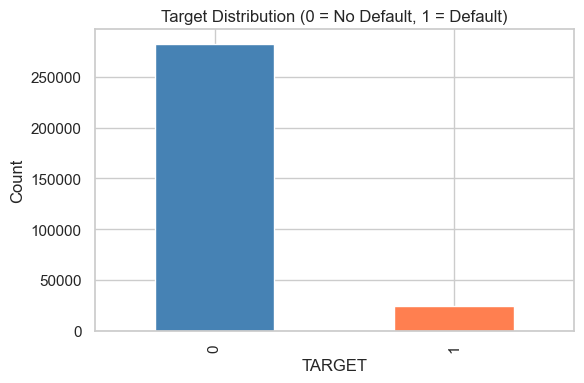

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
app_train[TARGET_COLUMN].value_counts().plot(kind="bar", ax=ax, color=["steelblue", "coral"])
ax.set_title("Target Distribution (0 = No Default, 1 = Default)")
ax.set_xlabel("TARGET")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
# TODO: More EDA (correlations, distributions, etc.)

In [ ]:
sample_df = app_train.sample(n=15000, random_state=RANDOM_SEED)  # sample 10k rows
sample_df = sample_df.dropna()  # drop rows with missing values for simplicity
for col in sample_df.columns:
    if sample_df[col].dtype in ['int64', 'float64']:  # numeric columns
        plt.figure(figsize=(6,4))
        sns.histplot(sample_df[col], kde=True, color='skyblue')
        plt.title(col)
        plt.show()

In [16]:
# 1. Najpierw podzielmy zbiór na train i test. Dalej będziemy patrzeć na X_train.
X = app_train.drop(columns=['TARGET'])
y = app_train['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y
)

# 2. Definiujemy zmienne kategoryczne. I listę nazw wszystkich kolumn.
categorical_vars = [col for col in app_train.columns if app_train[col].dtype == 'object'] 
variable_names = X_train.columns.tolist()

custom_params = {
    "gamma": 0.1,               
    
    "outlier_detector": "zscore" 
}

# 2.Tworzymy słownik, w którym key to kolejne elementy variable_names a wartości to custom_params
binning_fit_params = {col: custom_params for col in variable_names}

# 3. Optimal Binning
binning_process = BinningProcess(
    variable_names=variable_names,
    categorical_variables=categorical_vars,
    binning_fit_params=binning_fit_params, # Tutaj korzystamy z powyżej zdefiniowanego binning_fit_params
    max_n_bins=8,          # Więcej niż domyślnie, bo domyślnie jest 5.
    min_bin_size=0.05,  
    selection_criteria={"iv": {"min": 0.005}})

# 4.Fit tylko na zbiorze treningowym, ale przekształcenia stosujemy na obu.
binning_process.fit(X_train, y_train)

X_train_woe = binning_process.transform(X_train)
X_test_woe = binning_process.transform(X_test)

In [17]:
summary = binning_process.summary()
# Poniżej wypiszemy te top 15 cech pod względem IV oraz ich IV
top_15_summary = summary.sort_values("iv", ascending=False).head(60)

# Print clearly with Name and IV score
print("--- Final Model: Top 15 Features ---")
print(top_15_summary[['name', 'iv']].reset_index(drop=True))

--- Final Model: Top 15 Features ---
                                name        iv
0                       EXT_SOURCE_3  0.336256
1                       EXT_SOURCE_2  0.320924
2                       EXT_SOURCE_1  0.146735
3                 DAYS_CREDIT_median  0.126446
4          DAYS_CREDIT_UPDATE_median  0.099987
5                         DAYS_BIRTH  0.082832
6                    AMT_GOODS_PRICE  0.081364
7                    OCCUPATION_TYPE   0.08001
8         DAYS_CREDIT_ENDDATE_median  0.078045
9                    DAYS_CREDIT_max  0.076392
10                 ORGANIZATION_TYPE  0.069356
11                     DAYS_EMPLOYED  0.066201
12          DAYS_ENDDATE_FACT_median  0.065995
13           DAYS_CREDIT_ENDDATE_sum  0.061929
14             DAYS_ENDDATE_FACT_sum  0.057949
15    AMT_DRAWINGS_POS_CURRENT_count  0.055254
16    CNT_DRAWINGS_ATM_CURRENT_count  0.055254
17    AMT_DRAWINGS_ATM_CURRENT_count  0.055254
18  AMT_DRAWINGS_OTHER_CURRENT_count  0.055254
19  CNT_DRAWINGS_OTHER_

In [ ]:
# kolumny które mają sens - reszta to jakiś syf
selected_columns = [
    "SK_ID_CURR",
    "TARGET",
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "CNT_CHILDREN",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "REGION_POPULATION_RELATIVE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "DAYS_REGISTRATION",
    "DAYS_ID_PUBLISH",
    "OWN_CAR_AGE",
    "OCCUPATION_TYPE",
    "CNT_FAM_MEMBERS",
    "REGION_RATING_CLIENT_W_CITY",
    "OBS_60_CNT_SOCIAL_CIRCLE",
    "DEF_60_CNT_SOCIAL_CIRCLE"
]
app_train = app_train[selected_columns]

In [ ]:
numeric_df = app_train.select_dtypes(include=['number'])
corr = numeric_df.corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr, cmap='coolwarm', center=0, 
            xticklabels=True, yticklabels=True, 
            linewidths=0.5, annot = True)
plt.title("Correlation Matrix", fontsize=16)
plt.show()

In [ ]:
# patrząc na macierz korelacji wywalamy jeszcze następujące kolumny:
# AMT_GOODS_PRICE - bo mocno skorelowana z AMT_CREDIT
# CNT_CHILDREN - bo mocno skorelowana z CNT_FAM_MEMBERS (zostawiamy liczbę członków rodziny bo można nie mieć dzieci ale rodzinę już się pewnie jakąś ma)
app_train = app_train.drop(columns=["AMT_GOODS_PRICE", "CNT_CHILDREN"])

## 3. Feature Engineering

Create new features with **semantic, human-readable names**.

Example naming conventions:
- `income_to_credit_ratio` (not `feat_001`)
- `annuity_to_income_ratio` (not `ratio_2`)
- `bureau_active_credits_count` (not `bur_cnt`)

In [ ]:
# TODO: Load and aggregate supplementary data sources
bureau = pd.read_csv(DATA_DIR / "bureau.csv")
# 
# 
# pos_cash = pd.read_csv(DATA_DIR / "POS_CASH_balance.csv")
# installments = pd.read_csv(DATA_DIR / "installments_payments.csv")
# credit_card = pd.read_csv(DATA_DIR / "credit_card_balance.csv")

In [ ]:
bureau

In [ ]:
cols_to_delete = ['SK_ID_BUREAU', 'CREDIT_CURRENCY','CREDIT_DAY_OVERDUE','DAYS_CREDIT_ENDDATE', 'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG',
                  'AMT_CREDIT_SUM_DEBT','AMT_CREDIT_SUM_LIMIT', 'CREDIT_TYPE', 'DAYS_CREDIT_UPDATE', 'CNT_CREDIT_PROLONG' , 'AMT_CREDIT_SUM_LIMIT', 'AMT_CREDIT_SUM_OVERDUE', 'AMT_ANNUITY']
bureau = bureau[bureau["CREDIT_ACTIVE"] == "Active"].drop(columns=cols_to_delete).dropna()

In [ ]:
bureau["weighted_credit"] = bureau["AMT_CREDIT_SUM"] / bureau["DAYS_CREDIT"].abs()  
bureau.groupby("SK_ID_CURR")["weighted_credit"].sum().reset_index()

In [ ]:
sample_bureau = bureau.sample(n=30000, random_state=RANDOM_SEED)  # sample 10k rows
sample_bureau = sample_bureau.dropna()  # drop rows with missing values for simplicity
for col in sample_bureau.columns:
    if sample_bureau[col].dtype in ['int64', 'float64']:  # numeric columns
        plt.figure(figsize=(6,4))
        sns.histplot(sample_bureau[col], kde=True, color='skyblue')
        plt.title(col)
        plt.show()

In [ ]:
# Quick overview of missing values
missing_pct = (bureau.isnull().sum() / len(bureau) * 100).sort_values(ascending=False)
print(f"Columns with >50% missing:\n{missing_pct[missing_pct > 10]}")

In [ ]:
bureau_balance = pd.read_csv(DATA_DIR / "bureau_balance.csv")

In [ ]:
bureau_balance # --- IGNORE --- (syf)

In [ ]:
previous_app = pd.read_csv(DATA_DIR / "previous_application.csv")

In [ ]:
previous_app

In [ ]:
previous_app[previous_app["SK_ID_CURR"] == 100003]

In [ ]:
# --- Example feature engineering (extend this!) ---

df = app_train.copy()

# Ratio features (semantic names)
df["INCOME_TO_CREDIT_RATIO"] = df["AMT_INCOME_TOTAL"] / df["AMT_CREDIT"].replace(0, np.nan)
df["ANNUITY_TO_INCOME_RATIO"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"].replace(0, np.nan)
#df["CREDIT_TO_GOODS_RATIO"] = df["AMT_CREDIT"] / df["AMT_GOODS_PRICE"].replace(0, np.nan)
df["DAYS_EMPLOYED_RATIO"] = df["DAYS_EMPLOYED"] / df["DAYS_BIRTH"]

# External source aggregation
ext_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
df["EXTERNAL_SOURCES_MEAN"] = df[ext_cols].mean(axis=1)
df["EXTERNAL_SOURCES_STD"] = df[ext_cols].std(axis=1)

# TODO: Add other aggregates

print(f"Shape after feature engineering: {df.shape}")
df.head()

In [ ]:
# TODO:Handle missing values and encode categoricals
# TODO: Implement proper imputation strategy

print(f"Shape after preprocessing: {df.shape}")

## 4. Feature Selection

Select **15–20 features** using Boruta or Best Subset Selection.
This reduces dimensionality and improves interpretability of counterfactuals.

In [ ]:
# TODO: Implement feature selection

selected_features = None

print(f"Selected {len(selected_features)} features:\n{selected_features}")

## 5. Model Training

Train a tree-based classifier. LightGBM is recommended, but you may also
try XGBoost or CatBoost.

**Important:** Use `RANDOM_SEED = 42` for all random operations.

In [ ]:
# Prepare features and target
X = df[selected_features]
y = df[TARGET_COLUMN]

# Train/test split with fixed seed
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y,
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train target rate: {y_train.mean():.4f}")
print(f"Test target rate:  {y_test.mean():.4f}")

In [ ]:
# TODO: Train classifier

model = None 

print("\nTraining complete!")

In [ ]:
# TODO: Evaluate the model

# TODO: Print Roc AUC

# TODO: Plot ROC curve


In [ ]:
masterscale = pd.DataFrame({
    "Rating": [
        "AAA", "AA+", "AA", "AA-",
        "A+", "A", "A-",
        "BBB+", "BBB", "BBB-",
        "BB+", "BB", "BB-",
        "B+", "B", "B-",
        "CCC", "CC", "C", "D",
    ],
    "PD_lower": [
        0.0000, 0.0002, 0.0004, 0.0008,
        0.0015, 0.0025, 0.0040,
        0.0060, 0.0100, 0.0150,
        0.0250, 0.0400, 0.0600,
        0.1000, 0.1500, 0.2000,
        0.3000, 0.4000, 0.5000, 0.7000,
    ],
    "PD_upper": [
        0.0002, 0.0004, 0.0008, 0.0015,
        0.0025, 0.0040, 0.0060,
        0.0100, 0.0150, 0.0250,
        0.0400, 0.0600, 0.1000,
        0.1500, 0.2000, 0.3000,
        0.4000, 0.5000, 0.7000, 1.0000,
    ],
})

print(masterscale)

# TODO: Visualise the distribution of predicted probabilities and overlay the rating thresholds

# TODO: Decide the decision threshold (as the end of some rating), such will classify at least 10% as bad.

decision_threshold = None

In [ ]:
# TODO: Calculate the classification metrics

# TODO: Precision, recall, F1-score, confusion matrix, etc.

In [ ]:
# TODO: Plot SHAP summary plot

Provide a quick discussion how model works "globally"

## 6. Model Serialization

Save the trained model as a `.pkl` file in the `models/` directory.
This file **must be committed** to the repository.

In [ ]:
# Save model
model_path = MODELS_DIR / "final_model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(model, f)
print(f"Model saved to {model_path}")

# Verify: reload and check
with open(model_path, "rb") as f:
    loaded_model = pickle.load(f)
assert roc_auc_score(y_test, loaded_model.predict_proba(X_test)[:, 1]) == auc
print("Model verification passed!")

## 7. Counterfactual Analysis

### 7a. Select Interesting Test Examples

Choose 10–15 instances from the test set that are interesting for CE analysis:
- Near the decision boundary
- Correctly classified defaults
- Misclassified examples
- High-confidence edge cases

In [ ]:
# TODO: Select interesting examples based on prediction probability

interesting_examples = None

### 7b. DiCE — Diverse Counterfactual Explanations

Generate counterfactuals using the DiCE package.

Documentation: [github.com/interpretml/DiCE](https://github.com/interpretml/DiCE)

In [ ]:
# TODO: Implement DiCE counterfactual generation

### 7c. Alibi Explain — Counterfactual with Prototypes

Generate counterfactuals using the Alibi package.

Documentation: [docs.seldon.io/projects/alibi](https://docs.seldon.io/projects/alibi/en/stable/methods/CFProto.html)

In [ ]:
# TODO: Implement Alibi counterfactual generation

## 8. Evaluation & Benchmarking

In [ ]:
# TODO: Implement DiCE counterfactual generation

## 9. Summary & Next Steps

### What you have done:

---

### AI Tools Used

Document any AI tools used during this project:

| Tool | How it was used |
|------|----------------|
| *e.g., ChatGPT* | *e.g., Helped debug LightGBM hyperparameter tuning* |
| | |